# Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3489s 20us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

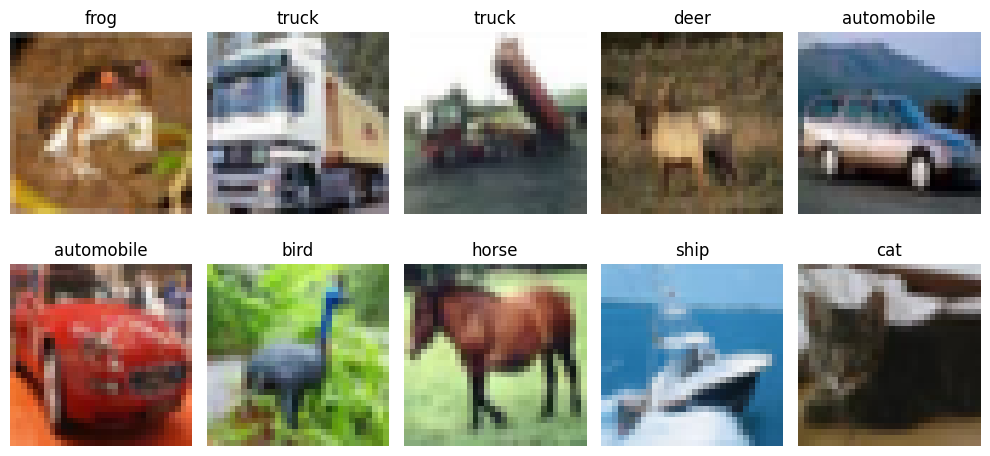

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2690 - loss: 1.9910 - val_accuracy: 0.3296 - val_loss: 1.8495
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3159 - loss: 1.8687 - val_accuracy: 0.3460 - val_loss: 1.7856
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3379 - loss: 1.8114 - val_accuracy: 0.3772 - val_loss: 1.7367
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3517 - loss: 1.7795 - val_accuracy: 0.3798 - val_loss: 1.7371
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3635 - loss: 1.7525 - val_accuracy: 0.3702 - val_loss: 1.7214
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.3704 - loss: 1.7319 - val_accuracy: 0.4232 - val_loss: 1.6687
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3780 - loss: 1.7081 - val_accuracy: 0.4156 - val_loss: 1.6682
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3817 - loss: 1.6999 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4299 - loss: 1.6291
ANN Test Accuracy: 0.42989999055862427


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.4634 - loss: 1.5051 - val_accuracy: 0.5516 - val_loss: 1.2579
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.5990 - loss: 1.1415 - val_accuracy: 0.5616 - val_loss: 1.3256
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.6598 - loss: 0.9710 - val_accuracy: 0.6368 - val_loss: 1.0266
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.6999 - loss: 0.8534 - val_accuracy: 0.6820 - val_loss: 0.9022
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.7320 - loss: 0.7571 - val_accuracy: 0.6256 - val_loss: 1.2544
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.7615 - loss: 0.6768 - val_accuracy: 0.7006 - val_loss: 0.8756
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.7870 - loss: 0.6038 - val_accuracy: 0.6964 - val_loss: 0.9204
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 129ms/step - accuracy: 0.8058 - l

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7238 - loss: 0.8868
CNN Test Accuracy: 0.723800003528595


## 📈 Compare Learning Curves

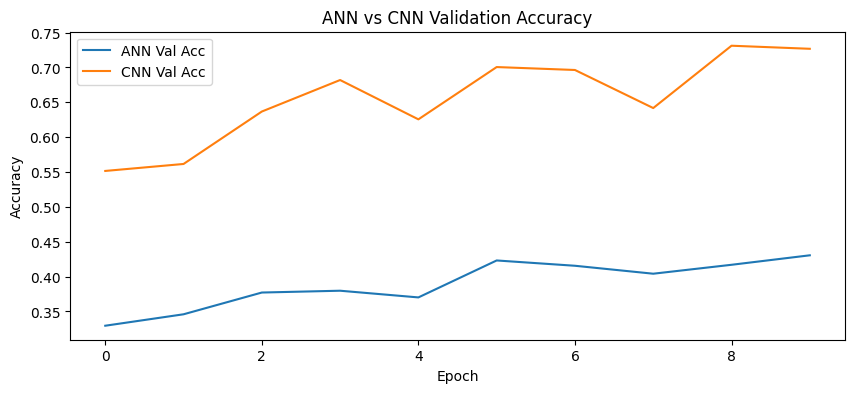

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [20]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.3702 - loss: 1.7209 - val_accuracy: 0.4840 - val_loss: 1.4451
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 55ms/step - accuracy: 0.4691 - loss: 1.4795 - val_accuracy: 0.5506 - val_loss: 1.2367
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 55ms/step - accuracy: 0.4994 - loss: 1.3946 - val_accuracy: 0.5738 - val_loss: 1.2580
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.5261 - loss: 1.3333 - val_accuracy: 0.5792 - val_loss: 1.1932
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.5407 - loss: 1.2924 - val_accuracy: 0.6014 - val_loss: 1.1201
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.5540 - loss: 1.2619 - val_accuracy: 0.6302 - val_loss: 1.0697
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.5642 - loss: 1.2361 - val_accuracy: 0.6246 - val_loss: 1.0751
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.5703 -

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4299
1,CNN,0.7238


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

> 1. Increase ANN layers and observe performance

In [12]:
ann_deep_model=models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann_deep_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_deep_history=ann_deep_model.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=64)
ann_deep_test_loss,ann_deep_test_acc=ann_deep_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:",ann_deep_test_acc,"|Original ANN:",ann_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 72ms/step - accuracy: 0.2480 - loss: 2.0263 - val_accuracy: 0.3064 - val_loss: 1.8961
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.3104 - loss: 1.8812 - val_accuracy: 0.3442 - val_loss: 1.8279
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 70ms/step - accuracy: 0.3325 - loss: 1.8302 - val_accuracy: 0.3712 - val_loss: 1.7578
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.3465 - loss: 1.7959 - val_accuracy: 0.3822 - val_loss: 1.7440
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3567 - loss: 1.7706 - val_accuracy: 0.3874 - val_loss: 1.7179
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3684 - loss: 1.7396 - val_accuracy: 0.3970 - val_loss: 1.7032
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3751 - loss: 1.7225 - val_accuracy: 0.4058 - val_loss: 1.6884
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3813 - loss: 1.7108 - 

> 2. Change CNN filters from 32→64→128

In [13]:
for layer in cnn_model.layers:
    if 'conv' in layer.name:
        print(layer.name, layer.filters)

conv2d 32
conv2d_1 64
conv2d_2 128


> 3. Increase epochs to 20

In [14]:
cnn_20_model=models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
cnn_20_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_20_history=cnn_20_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64)
cnn_20_test_loss,cnn_20_test_acc=cnn_20_model.evaluate(x_test_norm, y_test)
print("CNN 20-epoch Test Accuracy:",cnn_20_test_acc,"| CNN 10-epoch:",cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 128ms/step - accuracy: 0.4709 - loss: 1.4908 - val_accuracy: 0.4586 - val_loss: 1.6433
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6129 - loss: 1.1207 - val_accuracy: 0.6234 - val_loss: 1.0460
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.6671 - loss: 0.9602 - val_accuracy: 0.5428 - val_loss: 1.5346
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7106 - loss: 0.8410 - val_accuracy: 0.6754 - val_loss: 0.9275
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 127ms/step - accuracy: 0.7415 - loss: 0.7393 - val_accuracy: 0.6244 - val_loss: 1.1381
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 134ms/step - accuracy: 0.7689 - loss: 0.6639 - val_accuracy: 0.6928 - val_loss: 0.9058
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 147s 140ms/step - accuracy: 0.7921 - loss: 0.5935 - val_accuracy: 0.7148 - val_loss: 0.8976
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 137ms/step - accuracy: 0.8103 - loss

> 4. Add EarlyStopping

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

cnn_es_model=models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10,activation='softmax')
])
cnn_es_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
cnn_es_history=cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)
cnn_es_test_loss,cnn_es_test_acc=cnn_es_model.evaluate(x_test_norm,y_test)
print("CNN + EarlyStopping Test Accuracy:",cnn_es_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 126ms/step - accuracy: 0.4552 - loss: 1.5204 - val_accuracy: 0.5820 - val_loss: 1.1737
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.6020 - loss: 1.1365 - val_accuracy: 0.6222 - val_loss: 1.0663
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.6644 - loss: 0.9694 - val_accuracy: 0.6406 - val_loss: 1.0418
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7071 - loss: 0.8403 - val_accuracy: 0.6258 - val_loss: 1.1204
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.7400 - loss: 0.7478 - val_accuracy: 0.6604 - val_loss: 1.0211
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.7652 - loss: 0.6647 - val_accuracy: 0.6686 - val_loss: 0.9634
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 128ms/step - accuracy: 0.7930 - loss: 0.5927 - val_accuracy: 0.7104 - val_loss: 0.8713
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.8158 - loss:

> 5. Add data augmentation training

In [21]:
print("Data augmentation training already run above.")
print("Augmented CNN final val accuracy:", aug_history.history['val_accuracy'][-1])

Data augmentation training already run above.
Augmented CNN final val accuracy: 0.6453999876976013


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**